# Plug-and-Play HQS — Motion Deblurring and Denoising

Questo notebook usa Plug-and-Play HQS con denoiser congelato come metodo di ricostruzione per motion deblurring e denoising.

La degradazione è la stessa usata per TV:

- motion blur con kernel `9x9`;
- angolo del blur pari a `45°`;
- rumore gaussiano con livelli `[0.005, 0.01, 0.05, 0.1]`.

Per ogni immagine e per ogni livello di rumore vengono testati diversi schedule HQS.  
La migliore ricostruzione viene scelta in base al PSNR rispetto all'immagine pulita.

In [ ]:
# 1 - Setup, dataset, denoiser and regularizer

import os
from datasets import load_dataset
import torch
from torch.utils.data import Subset

from IPPy.utilities.metrics import PSNR, SSIM
from models.network_unet import UNetRes

from utilities.image_dataset import ImageDataset
from utilities.degradation import ImageDegradation, DegradationParameters, RGBBlurOperator
from utilities.plotter import plot 
from utilities.config import TEST_SIZE, TO_RECONSTRUCT_INDEXES
from models.heuristic_hqs_pnp import PnPHQSRegularizer, DRUNetDenoiser

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

IMAGE_SIZE = 256
NOISE_LEVELS = [0.005, 0.01, 0.05, 0.1]

RESULTS_DIR = "results/PnP_HQS"
DRUNET_PATH = "./weights/DRUNet/drunet_color.pth"

SCHEDULES = {
    "dpir_less_prior": {
        "iter_num": 8,
        "model_sigma_1": 49.0,
        "model_sigma_2": None,
        "w": 1.0,
        "rho_scale": 0.15,
        "cg_iters": 30,
    },
    "dpir_less_prior_10iters": {
        "iter_num": 10,
        "model_sigma_1": 49.0,
        "model_sigma_2": None,
        "w": 1.0,
        "rho_scale": 0.15,
        "cg_iters": 30,
    },
    "dpir_very_low_prior": {
        "iter_num": 8,
        "model_sigma_1": 49.0,
        "model_sigma_2": None,
        "w": 1.0,
        "rho_scale": 0.01,
        "cg_iters": 30,
    },
    "dpir_low_prior_stronger_start": {
        "iter_num": 8,
        "model_sigma_1": 60.0,
        "model_sigma_2": None,
        "w": 1.0,
        "rho_scale": 0.15,
        "cg_iters": 30,
    },
}


ds = load_dataset("benjamin-paine/imagenet-1k-256x256")

test_dataset = Subset(
    ImageDataset(ds["test"]),
    range(TEST_SIZE),
)


drunet = UNetRes(
    in_nc=4,
    out_nc=3,
    nc=[64, 128, 256, 512],
    nb=4,
    act_mode="R",
    downsample_mode="strideconv",
    upsample_mode="convtranspose",
    bias=False,
)

state_dict = torch.load(
    DRUNET_PATH,
    map_location=DEVICE,
    weights_only=False,
)

drunet.load_state_dict(state_dict, strict=True)
drunet.to(DEVICE)
drunet.eval()

for p in drunet.parameters():
    p.requires_grad = False


denoiser = DRUNetDenoiser(drunet).to(DEVICE)

pnp_hqs = PnPHQSRegularizer(
    denoiser=denoiser,
    schedules=SCHEDULES,
    cg_tol=1e-5,
    init_mode="degraded",
)

Resolving data files:   0%|          | 0/40 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/40 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/36 [00:00<?, ?it/s]

## Reconstruction

Per ogni immagine selezionata vengono generate quattro versioni degradate, una per ciascun livello di rumore.

Per ogni degradazione, PnP-HQS ricostruisce l'immagine usando tutti gli schedule definiti in `SCHEDULES`.  
La migliore ricostruzione viene selezionata in base al PSNR.

Running PnP-HQS reconstruction with schedule = dpir_less_prior
Done | PSNR=40.93 dB | SSIM=0.9837 | RE=0.0189
Running PnP-HQS reconstruction with schedule = dpir_less_prior_10iters
Done | PSNR=41.17 dB | SSIM=0.9844 | RE=0.0184
Running PnP-HQS reconstruction with schedule = dpir_very_low_prior
Done | PSNR=31.32 dB | SSIM=0.8104 | RE=0.0572
Running PnP-HQS reconstruction with schedule = dpir_low_prior_stronger_start
Done | PSNR=40.88 dB | SSIM=0.9835 | RE=0.0190


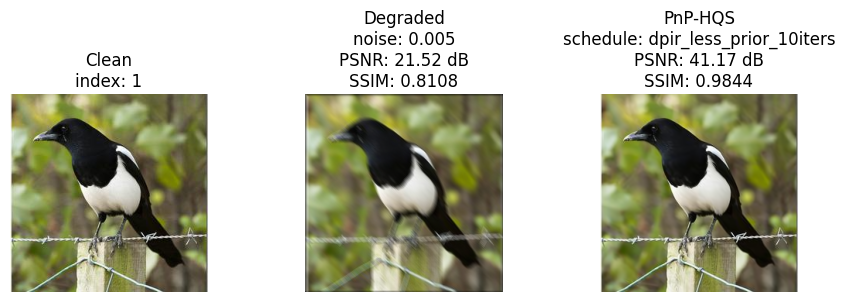

Running PnP-HQS reconstruction with schedule = dpir_less_prior
Done | PSNR=37.87 dB | SSIM=0.9710 | RE=0.0269
Running PnP-HQS reconstruction with schedule = dpir_less_prior_10iters
Done | PSNR=38.01 dB | SSIM=0.9717 | RE=0.0265
Running PnP-HQS reconstruction with schedule = dpir_very_low_prior
Done | PSNR=25.43 dB | SSIM=0.5786 | RE=0.1126
Running PnP-HQS reconstruction with schedule = dpir_low_prior_stronger_start
Done | PSNR=37.83 dB | SSIM=0.9707 | RE=0.0270


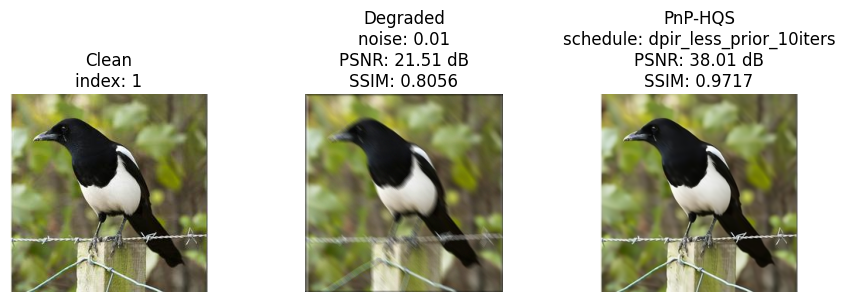

Running PnP-HQS reconstruction with schedule = dpir_less_prior
Done | PSNR=31.18 dB | SSIM=0.9223 | RE=0.0581
Running PnP-HQS reconstruction with schedule = dpir_less_prior_10iters
Done | PSNR=31.40 dB | SSIM=0.9234 | RE=0.0567
Running PnP-HQS reconstruction with schedule = dpir_very_low_prior
Done | PSNR=13.23 dB | SSIM=0.1547 | RE=0.4586
Running PnP-HQS reconstruction with schedule = dpir_low_prior_stronger_start
Done | PSNR=31.27 dB | SSIM=0.9225 | RE=0.0575


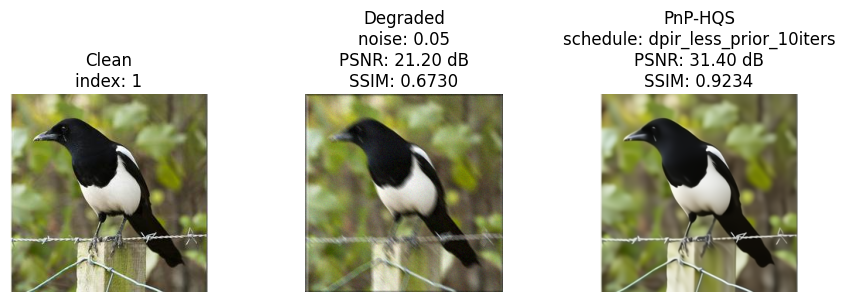

Running PnP-HQS reconstruction with schedule = dpir_less_prior
Done | PSNR=28.05 dB | SSIM=0.8817 | RE=0.0833
Running PnP-HQS reconstruction with schedule = dpir_less_prior_10iters
Done | PSNR=28.31 dB | SSIM=0.8838 | RE=0.0808
Running PnP-HQS reconstruction with schedule = dpir_very_low_prior
Done | PSNR=10.10 dB | SSIM=0.0804 | RE=0.6581
Running PnP-HQS reconstruction with schedule = dpir_low_prior_stronger_start
Done | PSNR=28.23 dB | SSIM=0.8826 | RE=0.0816


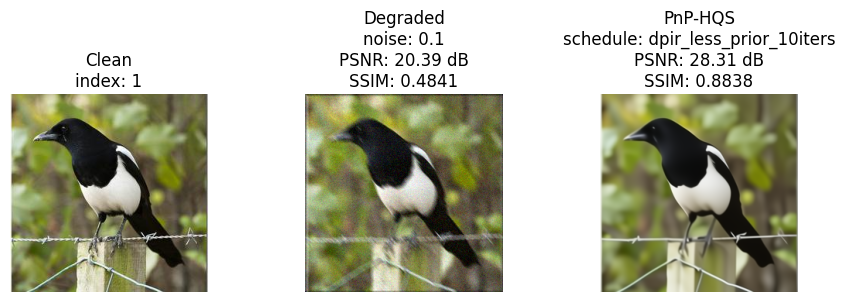

Running PnP-HQS reconstruction with schedule = dpir_less_prior
Done | PSNR=36.66 dB | SSIM=0.9715 | RE=0.0428
Running PnP-HQS reconstruction with schedule = dpir_less_prior_10iters
Done | PSNR=37.11 dB | SSIM=0.9741 | RE=0.0406
Running PnP-HQS reconstruction with schedule = dpir_very_low_prior
Done | PSNR=34.56 dB | SSIM=0.9523 | RE=0.0545
Running PnP-HQS reconstruction with schedule = dpir_low_prior_stronger_start
Done | PSNR=36.54 dB | SSIM=0.9708 | RE=0.0433


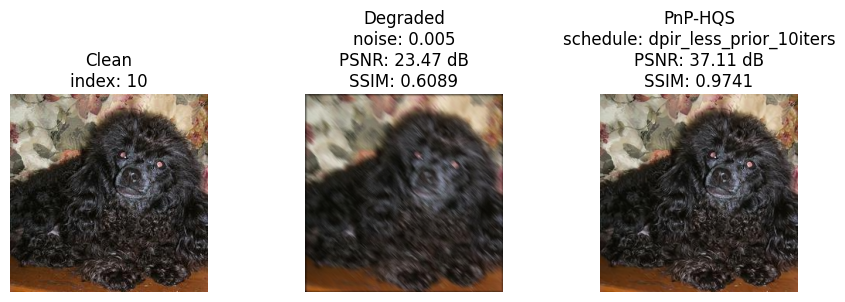

Running PnP-HQS reconstruction with schedule = dpir_less_prior
Done | PSNR=33.04 dB | SSIM=0.9333 | RE=0.0649
Running PnP-HQS reconstruction with schedule = dpir_less_prior_10iters
Done | PSNR=33.35 dB | SSIM=0.9373 | RE=0.0626
Running PnP-HQS reconstruction with schedule = dpir_very_low_prior
Done | PSNR=28.83 dB | SSIM=0.8479 | RE=0.1053
Running PnP-HQS reconstruction with schedule = dpir_low_prior_stronger_start
Done | PSNR=32.95 dB | SSIM=0.9320 | RE=0.0656


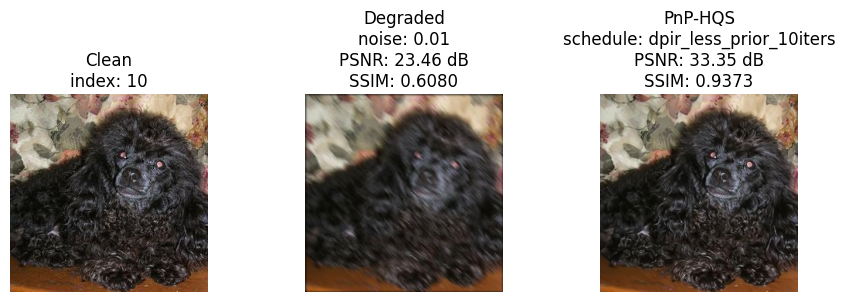

Running PnP-HQS reconstruction with schedule = dpir_less_prior
Done | PSNR=26.33 dB | SSIM=0.7114 | RE=0.1406
Running PnP-HQS reconstruction with schedule = dpir_less_prior_10iters


KeyboardInterrupt: 

In [11]:
# 2 - PnP-HQS reconstruction on selected test images

all_hqs_results = []

for image_index in TO_RECONSTRUCT_INDEXES:
    clean = test_dataset[image_index].unsqueeze(0).to(DEVICE)

    for noise_level in NOISE_LEVELS:
        noise_name = f"noise_{int(noise_level * 1000):03d}"

        degradation = ImageDegradation(
            DegradationParameters(
                image_size=IMAGE_SIZE,
                kernel_type="motion",
                kernel_size=9,
                motion_angle=45,
                noise_levels=[noise_level],
            )
        )

        K_rgb = RGBBlurOperator(degradation.operator)
        degraded = degradation(clean)

        image_dir = os.path.join(
            RESULTS_DIR,
            noise_name,
            f"image_{image_index}",
        )

        results = pnp_hqs(
            y_d=degraded,
            K=K_rgb,
            noise_level=noise_level,
            x_gt=clean,
            save_dir=None,
            preview=False,
        )

        best_result = max(
            results,
            key=lambda result: result["psnr"],
        )

        best_reconstruction = best_result["reconstruction"]

        psnr_degraded = PSNR(degraded, clean)
        ssim_degraded = SSIM(degraded, clean)

        summary = {
            "image_index": image_index,
            "noise_level": noise_level,
            "best_schedule": best_result["schedule"],
            "psnr_degraded": psnr_degraded,
            "ssim_degraded": ssim_degraded,
            "psnr_hqs": best_result["psnr"],
            "ssim_hqs": best_result["ssim"],
            "re_hqs": best_result["re"],
        }

        all_hqs_results.append(summary)

        plot(
            clean,
            degraded,
            best_reconstruction,
            titles=[
                f"Clean\nindex: {image_index}",
                (
                    f"Degraded\n"
                    f"noise: {noise_level}\n"
                    f"PSNR: {psnr_degraded:.2f} dB\n"
                    f"SSIM: {ssim_degraded:.4f}"
                ),
                (
                    f"PnP-HQS\n"
                    f"schedule: {best_result['schedule']}\n"
                    f"PSNR: {best_result['psnr']:.2f} dB\n"
                    f"SSIM: {best_result['ssim']:.4f}"
                ),
            ],
            save_path=os.path.join(
                image_dir,
                "best_pnp_hqs.png",
            ),
            dpi=150,
        )

        torch.save(
            {
                "image_index": image_index,
                "noise_level": noise_level,
                "best_schedule": best_result["schedule"],
                "best_reconstruction": best_reconstruction.detach().cpu(),
                "psnr_degraded": psnr_degraded,
                "ssim_degraded": ssim_degraded,
                "psnr_hqs": best_result["psnr"],
                "ssim_hqs": best_result["ssim"],
                "re_hqs": best_result["re"],
            },
            os.path.join(
                image_dir,
                "best_pnp_hqs.pt",
            ),
        )

torch.save(
    all_hqs_results,
    os.path.join(
        RESULTS_DIR,
        "pnp_hqs_summary.pt",
    ),
)

for result in all_hqs_results:
    print(
        f"image={result['image_index']} | "
        f"noise={result['noise_level']} | "
        f"best schedule={result['best_schedule']} | "
        f"degraded PSNR={result['psnr_degraded']:.2f} dB | "
        f"PnP-HQS PSNR={result['psnr_hqs']:.2f} dB | "
        f"PnP-HQS SSIM={result['ssim_hqs']:.4f} | "
        f"PnP-HQS RE={result['re_hqs']:.4f}"
    )